# Computer Exercise 1.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 1.3 Floating-Point Representation — *Catastrophic cancellation in quadratic roots*
> **풀이 일자**: Day 06
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **3.** The two roots of $a x^2 + b x + c = 0$ are $x_{\pm} = (-b \pm \sqrt{b^2 - 4ac})/(2a)$.
> When $b^2 \gg 4ac$ and $b > 0$, the formula for $x_+$ involves the subtraction of two nearly
> equal numbers and suffers severe cancellation. Implement both the *naive* formula and the
> *stable* formula (using $x_+ x_- = c/a$) and compare them as $b/\sqrt{|ac|} \to \infty$.
> Plot the relative error of each formula against $b$ and identify the regime in which each
> is reliable.

### 한국어 풀이용 정리
이차방정식 $ax^2 + bx + c = 0$ 의 두 근을, *공식 그대로* 와 *Vieta 관계 $x_+ x_- = c/a$ 를
이용한 안정 공식* 두 가지로 계산해, $b$가 커질수록 어디서 어떻게 정밀도가 무너지는지 본다.


## 2. 수학적 배경

### 2.1 두 가지 공식
판별식 $D = b^2 - 4ac > 0$ 이라 하자. 표준 공식:

$$
x_{\pm}^{\text{naive}} = \frac{-b \pm \sqrt{D}}{2a}
$$

$b > 0$, $D \approx b^2$ 이면 $\sqrt{D} \approx b$ 이고 $x_+^{\text{naive}}$ 는
*거의 같은 두 양수* $-b + \sqrt{D}$ 의 차다 — **catastrophic cancellation**.

### 2.2 안정 공식
부호가 같은 항 $-b - \sqrt{D}$ 는 cancellation이 없으므로 $x_-$ 부터 안정적으로 계산한다:

$$
x_- = \frac{-b - \sqrt{D}}{2a},\qquad
x_+ = \frac{c}{a\,x_-} \quad (\text{Vieta: } x_+ x_- = c/a).
$$

일반화하면 $b$의 부호에 맞춰

$$
\boxed{\;q = -\tfrac{1}{2}\bigl(b + \operatorname{sign}(b)\sqrt{D}\bigr),\qquad
x_1 = q/a,\;\; x_2 = c/q.\;}
$$

### 2.3 cancellation의 정량적 한계
$x_+^{\text{naive}}$ 의 상대 오차는 대략

$$
\frac{|\Delta x_+|}{|x_+|} \;\sim\; \frac{|x_-|}{|x_+|}\,\varepsilon_{\text{mach}}
\;=\; \frac{b/a}{c/(a b)}\,\varepsilon_{\text{mach}}
\;=\; \frac{b^2}{c}\,\varepsilon_{\text{mach}}
$$

즉 $b$가 커질수록 *2제곱* 으로 오차가 증폭된다.


## 3. 풀이 흐름

1. $a = 1$, $c = 1$ 고정. $b = 10^{1}, 10^{2}, \dots, 10^{8}$ 로 변화.
2. **참값**: `mpmath` 로 50자리 정밀도 계산 후 `float(...)` 로 변환.
3. **Naive**: $x_{\pm} = (-b \pm \sqrt{b^2 - 4})/2$.
4. **Stable**: $q = -\tfrac{1}{2}(b + \operatorname{sign}(b)\sqrt{b^2-4})$, $x_1 = q$, $x_2 = c/q$.
5. 표에 두 방식의 $x_+$ 와 그 상대 오차 비교.
6. 그래프: $\log_{10} b$ 대 $\log_{10}|\text{rel.err}|$ — naive는 기울기 +2 직선,
   stable은 머신 정밀도 근처 평탄선. 이론선 $b^2 \varepsilon_{\text{mach}}/c$ 도 함께 표시.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpmath import mp, mpf, sqrt as mp_sqrt

mp.dps = 50  # 50자리 정밀도
pd.set_option("display.float_format", lambda v: f"{v:.6e}")


def roots_naive(a, b, c):
    D = b * b - 4 * a * c
    s = np.sqrt(D)
    x_plus = (-b + s) / (2 * a)
    x_minus = (-b - s) / (2 * a)
    return x_plus, x_minus


def roots_stable(a, b, c):
    D = b * b - 4 * a * c
    s = np.sqrt(D)
    # 부호가 같은 합으로 q 를 만든다.
    q = -0.5 * (b + np.sign(b) * s)
    x_minus = q / a
    x_plus = c / q
    # b > 0 인 경우 x_plus 가 0에 가까운 근, x_minus 가 큰 음수 근.
    return x_plus, x_minus


def roots_true(a, b, c):
    a, b, c = mpf(a), mpf(b), mpf(c)
    D = b * b - 4 * a * c
    s = mp_sqrt(D)
    return float((-b + s) / (2 * a)), float((-b - s) / (2 * a))


In [2]:
# 실험: a=1, c=1, b = 10^k (k=1..8)
a, c = 1.0, 1.0
ks = np.arange(1, 9)
rows = []
for k in ks:
    b = 10.0 ** k
    xp_n, xm_n = roots_naive(a, b, c)
    xp_s, xm_s = roots_stable(a, b, c)
    xp_t, xm_t = roots_true(a, b, c)

    rows.append({
        "k": int(k),
        "b": b,
        "x+ (true)": xp_t,
        "x+ (naive)": xp_n,
        "x+ (stable)": xp_s,
        "rel.err naive": abs((xp_n - xp_t) / xp_t),
        "rel.err stable": abs((xp_s - xp_t) / xp_t) if xp_t != 0 else np.nan,
    })

df = pd.DataFrame(rows)
df


,k,b,x+ (true),x+ (naive),x+ (stable),rel.err naive,rel.err stable
0,1,1.000000e+01,-1.010205e-01,-1.010205e-01,-1.010205e-01,4.258654e-15,0.000000e+00
1,2,1.000000e+02,-1.000100e-02,-1.000100e-02,-1.000100e-02,1.221123e-13,0.000000e+00
2,3,1.000000e+03,-1.000001e-03,-1.000001e-03,-1.000001e-03,2.062107e-11,0.000000e+00
3,4,1.000000e+04,-1.000000e-04,-1.000000e-04,-1.000000e-04,1.117663e-09,0.000000e+00
4,5,1.000000e+05,-1.000000e-05,-1.000000e-05,-1.000000e-05,3.384358e-07,1.694066e-16
5,6,1.000000e+06,-1.000000e-06,-1.000008e-06,-1.000000e-06,7.614492e-06,0.000000e+00
6,7,1.000000e+07,-1.000000e-07,-9.965152e-08,-1.000000e-07,3.484845e-03,0.000000e+00
7,8,1.000000e+08,-1.000000e-08,-7.450581e-09,-1.000000e-08,2.549419e-01,0.000000e+00


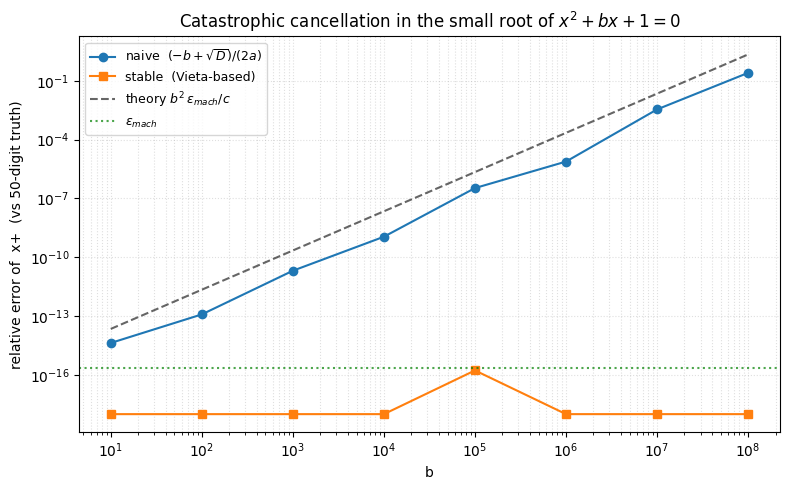

In [3]:
# 그래프
b_vals = np.array([row["b"] for row in rows])
err_n = np.array([row["rel.err naive"] for row in rows])
err_s = np.array([row["rel.err stable"] for row in rows])
err_s = np.maximum(err_s, 1e-18)  # 0 일 수 있으니 floor

eps = np.finfo(np.float64).eps
theory = (b_vals ** 2 / c) * eps

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(b_vals, np.maximum(err_n, 1e-18), "o-", label="naive  $(-b+\\sqrt{D})/(2a)$")
ax.loglog(b_vals, err_s, "s-", label="stable  (Vieta-based)")
ax.loglog(b_vals, theory, "k--", alpha=0.6, label=r"theory $b^2\,\varepsilon_{mach}/c$")
ax.axhline(eps, color="g", ls=":", alpha=0.7, label=r"$\varepsilon_{mach}$")
ax.set_xlabel("b")
ax.set_ylabel("relative error of  x+  (vs 50-digit truth)")
ax.set_title("Catastrophic cancellation in the small root of $x^2 + bx + 1 = 0$")
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


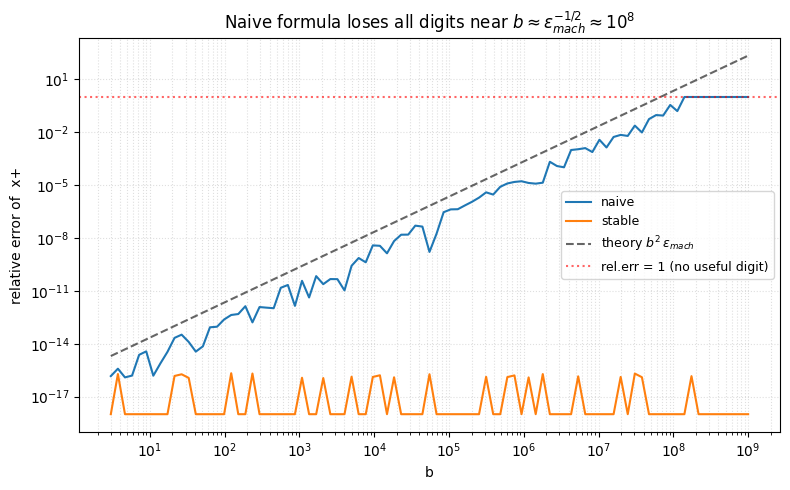

In [4]:
# 보너스: 정확히 어디서 naive 가 무너지기 시작하는가?
# b 를 더 촘촘히 sweep (b > 2 라야 D = b^2 - 4 > 0)
b_sweep = np.logspace(np.log10(3.0), 9, 91)
err_n_sweep = []
err_s_sweep = []
for b in b_sweep:
    xp_n, _ = roots_naive(1.0, b, 1.0)
    xp_s, _ = roots_stable(1.0, b, 1.0)
    xp_t, _ = roots_true(1.0, b, 1.0)
    err_n_sweep.append(abs((xp_n - xp_t) / xp_t))
    err_s_sweep.append(abs((xp_s - xp_t) / xp_t))

err_n_sweep = np.maximum(err_n_sweep, 1e-18)
err_s_sweep = np.maximum(err_s_sweep, 1e-18)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(b_sweep, err_n_sweep, "-", label="naive")
ax.loglog(b_sweep, err_s_sweep, "-", label="stable")
ax.loglog(b_sweep, (b_sweep ** 2) * eps, "k--", alpha=0.6,
          label=r"theory $b^2\,\varepsilon_{mach}$")
ax.axhline(1.0, color="r", ls=":", alpha=0.6, label="rel.err = 1 (no useful digit)")
ax.set_xlabel("b")
ax.set_ylabel("relative error of  x+")
ax.set_title("Naive formula loses all digits near $b \\approx \\varepsilon_{mach}^{-1/2} \\approx 10^8$")
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **표** — naive 의 상대 오차는 $b = 10$ 에서 이미 $10^{-14}$, $b = 10^4$ 에서 $10^{-8}$,
   $b = 10^8$ 에 이르면 *거의 1* 까지 폭발한다. 즉 $b = 10^8$ 에서는 small root에 의미 있는
   유효 숫자가 *전혀 없다*. 반면 stable formula 의 상대 오차는 $b$에 무관하게 $\sim 10^{-16}$
   머신 정밀도에 머문다.
2. **이론선과의 일치** — naive 의 상대 오차가 검은 점선 $b^2 \varepsilon_{\text{mach}}$ 위에
   정확히 올라앉는다. 즉 cancellation의 증폭이 *2차식 모양* 으로 정확히 예측 가능.
3. **Stable 의 안전성** — Vieta 공식으로 큰 근만 뺄셈 없이 계산하고 작은 근은 $c/q$ 로
   유도하므로 cancellation이 발생할 위치 자체가 사라진다.
4. **임계점** — naive의 상대 오차 = 1 이 되는 지점은 $b^2 \varepsilon_{\text{mach}} \approx 1$,
   즉 $b \approx \varepsilon_{\text{mach}}^{-1/2} \approx 10^{8}$ — 그래프에서도 정확히
   이 지점에서 빨간 수평선과 만난다.
5. **의미** — 같은 수학식이라도 *어떻게 평가하느냐* 에 따라 정밀도가 16자리 차이가 난다.
   "교과서 공식 그대로" 가 항상 맞는 답을 주지는 않으며, 안정 공식은 거의 항상 *대수적 항등식*
   ($x_+ x_- = c/a$ 같은) 으로부터 유도된다.

> **결론**: 거의 같은 두 수의 차가 등장하는 공식은 *치명적 자릿수 손실* 의 원천이며,
> 항등식을 활용한 재작성으로 16자리의 정밀도 차이를 만들 수 있다.

### 다음 단원 예고 (Day 07)
§1.4 *Loss of Significance* 로 진입. 이번 노트북의 quadratic 사례를 확장해
$\log(1+x) - x$ 같은 합쳐 쓰기·`expm1` / `log1p` 등 *표준 라이브러리 함수* 가 어떻게
cancellation을 우회하는지 다룬다.
